Main notebook for coding and testing.

<header>
    <h1>Install Dependencies</h1>
</header>

In [ ]:
#%pip install --upgrade pip

# %pip install pandas 
# %pip install numpy 
# %pip install matplotlib 
# %pip install seaborn
# %pip install xlrd
# %pip install scipy
#%pip install statsmodels
#%pip install pandas-datareader
#%pip install fredapi

<header>
    <h2>Import Libraries</h2>
</header>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from fredapi import Fred
import datetime

<header>
    <h2>Import Functions from Source Files</h2>
</header>

In [29]:
from src.CAPM_regression import fit_ols 
from src.visualize import plot_correlation_matrix, plot_regression
from src.sentiment_strategies import calculate_sentiment_signal, calculate_return

<header>
    <h1>Basic Data Cleaning</h1>
    <bullet>
        <li>Read in sentiment data from AAII</li>
        <li>Get rid of extra data at the bottom of the file (row <= 2020)</li>
        <li>Convert date column to datetime format</li>
        <li>Get rid of useless columns</li>
        <li>Rename columns for ease</li>
        <li>output to .pkl file</li>
    </bullet>
</header>

In [ ]:
# sentiment_data = pd.read_excel('data/sentiment_data.xls', header=3)

In [ ]:
# cleaned_sentiment_data = sentiment_data[sentiment_data.index <= 2020]

# cleaned_sentiment_data['Date'] = pd.to_datetime(cleaned_sentiment_data['Date'])

# cleaned_sentiment_data = cleaned_sentiment_data[cleaned_sentiment_data['Date'].notna()].drop(columns=['Unnamed: 13'])

# cleaned_sentiment_data = cleaned_sentiment_data.rename(columns={'High':'S&P High', 'Low':'S&P Low', 'Close':'S&P Close'})

# display(cleaned_sentiment_data)

# pd.to_pickle(cleaned_sentiment_data, 'cleaned_sentiment_data.pkl')



<header>
    <h2>More Data Cleaning</h2>
    <bullet>
        <li>Read in .pkl file from previous step</li>
        <li>Get rid of more useless columns</li>
        <li>Ensure datetime format</li>
    </bullet>
</header>

In [30]:
s_df = pd.read_pickle('data/cleaned_sentiment_data.pkl')

s_df.drop(columns = ['Total', 'Average', '+St. Dev.', '- St. Dev.'], inplace = True)

s_df['Date'] = pd.to_datetime(s_df['Date'])

display(s_df)

,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00
...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90


<header>
    <h1>Import Fred Data via API</h1>
    <bullet>
        <li>Use API to import weekly, 6monthrisk free rate data </li>
        <li>
    </bullet>
</header>

In [ ]:
fred = Fred(api_key='2156df4aac1a73d06c92ece4a988135f')
start = datetime.datetime(s_df['Date'].iloc[0].year, 1, 1)
end = datetime.datetime.today()

rf_data = (fred.get_series('WTB3MS', start, end)/100)

rf_data = rf_data.reindex(s_df['Date'], method='ffill')

display((rf_data))

Date
1987-06-26    0.001110
1987-07-17    0.001073
1987-07-24    0.001088
1987-07-31    0.001142
1987-08-07    0.001129
                ...   
2026-03-05    0.000692
2026-03-12    0.000692
2026-03-19    0.000694
2026-03-26    0.000696
2026-04-02    0.000698
Length: 2020, dtype: float64

In [32]:
s_df['Risk-Free Rate'] = rf_data.to_numpy()
display(s_df)


,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,Risk-Free Rate
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001110
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59,0.001073
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27,0.001088
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66,0.001142
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00,0.001129
...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50,0.000692
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80,0.000692
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70,0.000694
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90,0.000696


In [33]:
display(s_df.info())

display(s_df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 2020 entries, 1 to 2020
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2020 non-null   datetime64[us]
 1   Bullish         2017 non-null   float64       
 2   Neutral         2017 non-null   float64       
 3   Bearish         2017 non-null   float64       
 4   Mov Avg         2003 non-null   float64       
 5   Spread          2017 non-null   float64       
 6   S&P High        2019 non-null   float64       
 7   S&P Low         2019 non-null   float64       
 8   S&P Close       2019 non-null   float64       
 9   Risk-Free Rate  2020 non-null   float64       
dtypes: datetime64[us](1), float64(9)
memory usage: 157.9 KB


None

,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,Risk-Free Rate
count,2020,2017.000000,2017.000000,2017.000000,2003.000000,2017.000000,2019.000000,2019.000000,2019.000000,2020.000000
mean,2006-11-18 05:40:02.376237,0.376221,0.310635,0.313143,0.375845,0.063077,1776.076360,1729.207499,1756.605254,0.000577
min,1987-06-26 00:00:00,0.120000,0.076900,0.060000,0.175000,-0.540000,233.450000,223.920000,223.920000,-0.000002
25%,1997-03-11 06:00:00,0.303000,0.252000,0.240625,0.319334,-0.058900,790.305000,764.530000,775.025000,0.000062
50%,2006-11-19 12:00:00,0.372500,0.310000,0.300000,0.375628,0.070000,1277.630000,1253.120000,1267.430000,0.000582
75%,2016-07-22 18:00:00,0.440000,0.365759,0.373984,0.428887,0.187310,2151.989990,2099.885000,2132.514966,0.000962
max,2026-04-02 00:00:00,0.750000,0.620000,0.702700,0.644650,0.628600,7002.280000,6899.330000,6978.030000,0.001731
std,NaN,0.100208,0.081395,0.098547,0.078673,0.181330,1515.280246,1476.109334,1500.016716,0.000462


From the raw means we can see that Bullish has a mean of 37.%, Neutral has 31.06% and Bearish has 31.31%. This suggests that investors predicted bull more often. 

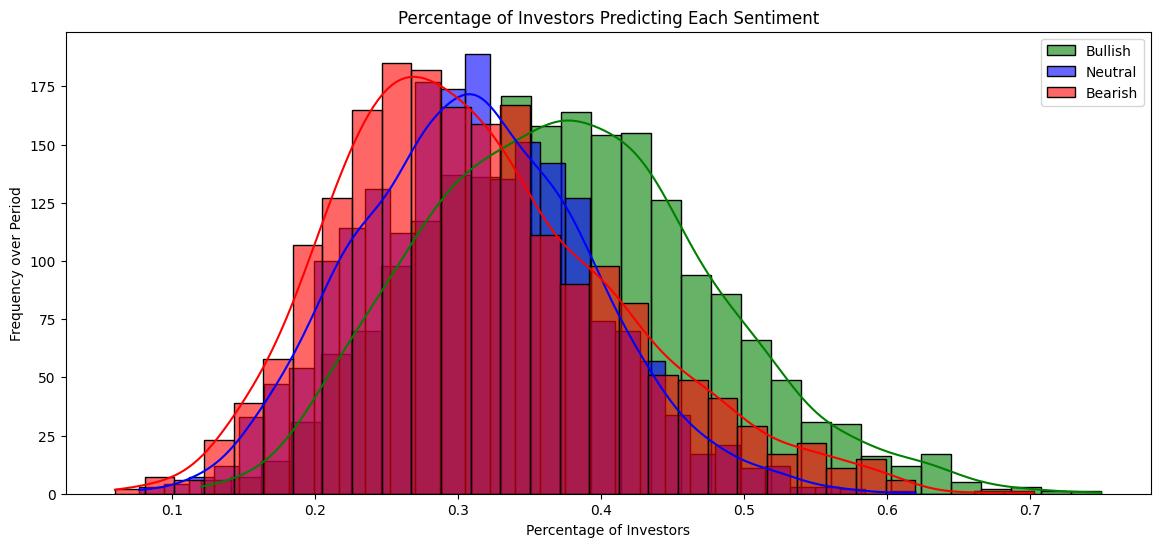

In [34]:
plt.figure(figsize=(14,6))

sns.histplot(s_df['Bullish'], kde=True, color='green', label='Bullish', alpha=0.6)
sns.histplot(s_df['Neutral'], kde=True, color='blue', label='Neutral', alpha=0.6)
sns.histplot(s_df['Bearish'], kde=True, color='red', label='Bearish', alpha=0.6)


plt.title('Percentage of Investors Predicting Each Sentiment')
plt.xlabel('Percentage of Investors')
plt.ylabel('Frequency over Period')
plt.legend()
plt.show()

In [36]:
s_df['Weekly Return'] = (s_df['S&P Close'].shift(-1)/s_df['S&P Close']) - 1 #forward weekly return

s_df['Next 6M Return'] = (s_df['S&P Close'].shift(-26) / s_df['S&P Close']) - 1 #forward monthly return

s_df['Excess Weekly Market Return'] = s_df['Weekly Return'] - s_df['Risk-Free Rate'] #excess foward weekly returns

s_df['Excess Next 6M Market Return'] = s_df['Next 6M Return'] - s_df['Risk-Free Rate'] #excess foward weekly returns

display(s_df)

#pd.to_pickle(s_df, f'data/{str(datetime.datetime.today())[:9]}_cleaned_sentiment_data.pkl')

s_df['Market Weekly Return Direction'] = np.sign(s_df['Excess Weekly Market Return'])

s_df['Market Next 6M Return Direction'] = np.sign(s_df['Excess Next 6M Market Return'])


display(s_df)

display(s_df.describe())

display(s_df['Next 6M Return'].isna().value_counts())




,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,Risk-Free Rate,Weekly Return,Next 6M Return,Excess Weekly Market Return,Excess Next 6M Market Return
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001110,NaN,NaN,NaN,NaN
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59,0.001073,-0.016911,-0.198798,-0.017984,-0.199872
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27,0.001088,0.030362,-0.202962,0.029273,-0.204050
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66,0.001142,0.013620,-0.193278,0.012477,-0.194420
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00,0.001129,0.034025,-0.223034,0.032896,-0.224163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50,0.000692,-0.013640,NaN,-0.014332,NaN
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80,0.000692,-0.022300,NaN,-0.022992,NaN
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70,0.000694,-0.004951,NaN,-0.005645,NaN
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90,0.000696,-0.002515,NaN,-0.003211,NaN


,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,Risk-Free Rate,Weekly Return,Next 6M Return,Excess Weekly Market Return,Excess Next 6M Market Return,Market Weekly Return Direction,Market Next 6M Return Direction
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001110,NaN,NaN,NaN,NaN,NaN,NaN
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59,0.001073,-0.016911,-0.198798,-0.017984,-0.199872,-1.0,-1.0
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27,0.001088,0.030362,-0.202962,0.029273,-0.204050,1.0,-1.0
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66,0.001142,0.013620,-0.193278,0.012477,-0.194420,1.0,-1.0
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00,0.001129,0.034025,-0.223034,0.032896,-0.224163,1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50,0.000692,-0.013640,NaN,-0.014332,NaN,-1.0,NaN
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80,0.000692,-0.022300,NaN,-0.022992,NaN,-1.0,NaN
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70,0.000694,-0.004951,NaN,-0.005645,NaN,-1.0,NaN
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90,0.000696,-0.002515,NaN,-0.003211,NaN,-1.0,NaN


,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,Risk-Free Rate,Weekly Return,Next 6M Return,Excess Weekly Market Return,Excess Next 6M Market Return,Market Weekly Return Direction,Market Next 6M Return Direction
count,2020,2017.000000,2017.000000,2017.000000,2003.000000,2017.000000,2019.000000,2019.000000,2019.000000,2020.000000,2018.000000,1993.000000,2018.000000,1993.000000,2018.000000,1993.000000
mean,2006-11-18 05:40:02.376237,0.376221,0.310635,0.313143,0.375845,0.063077,1776.076360,1729.207499,1756.605254,0.000577,0.001766,0.048164,0.001189,0.047589,0.135778,0.478174
min,1987-06-26 00:00:00,0.120000,0.076900,0.060000,0.175000,-0.540000,233.450000,223.920000,223.920000,-0.000002,-0.151689,-0.440878,-0.151851,-0.441203,-1.000000,-1.000000
25%,1997-03-11 06:00:00,0.303000,0.252000,0.240625,0.319334,-0.058900,790.305000,764.530000,775.025000,0.000062,-0.009016,-0.002304,-0.009733,-0.002818,-1.000000,-1.000000
50%,2006-11-19 12:00:00,0.372500,0.310000,0.300000,0.375628,0.070000,1277.630000,1253.120000,1267.430000,0.000582,0.003456,0.056597,0.002963,0.055853,1.000000,1.000000
75%,2016-07-22 18:00:00,0.440000,0.365759,0.373984,0.428887,0.187310,2151.989990,2099.885000,2132.514966,0.000962,0.014092,0.111588,0.013569,0.110705,1.000000,1.000000
max,2026-04-02 00:00:00,0.750000,0.620000,0.702700,0.644650,0.628600,7002.280000,6899.330000,6978.030000,0.001731,0.113127,0.432530,0.113129,0.432484,1.000000,1.000000
std,NaN,0.100208,0.081395,0.098547,0.078673,0.181330,1515.280246,1476.109334,1500.016716,0.000462,0.022640,0.105338,0.022644,0.105318,0.990985,0.878486


Next 6M Return
False    1993
True       27
Name: count, dtype: int64

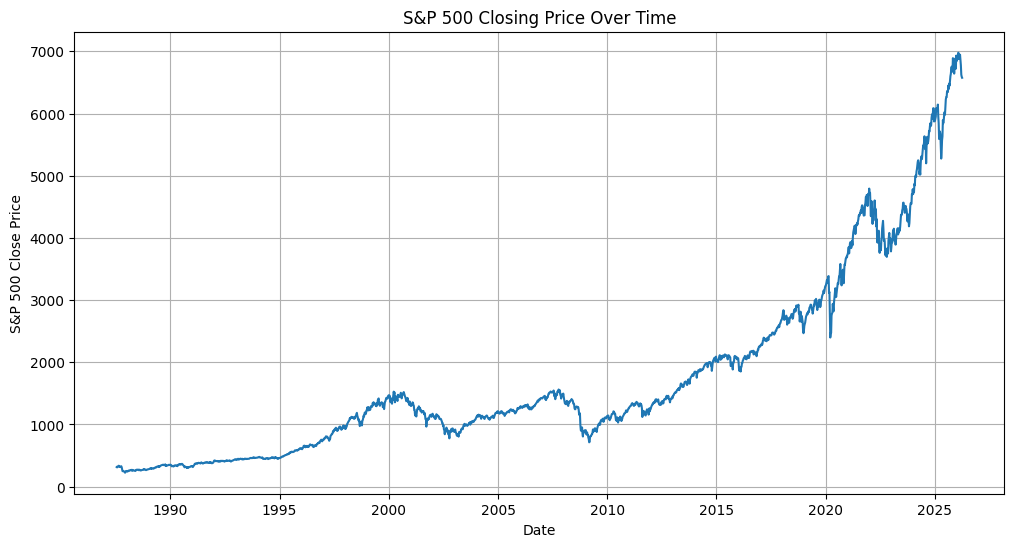

In [37]:
plt.figure(figsize=(12,6))
sns.lineplot(data=s_df, x='Date', y='S&P Close')
plt.title('S&P 500 Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500 Close Price')
plt.grid()



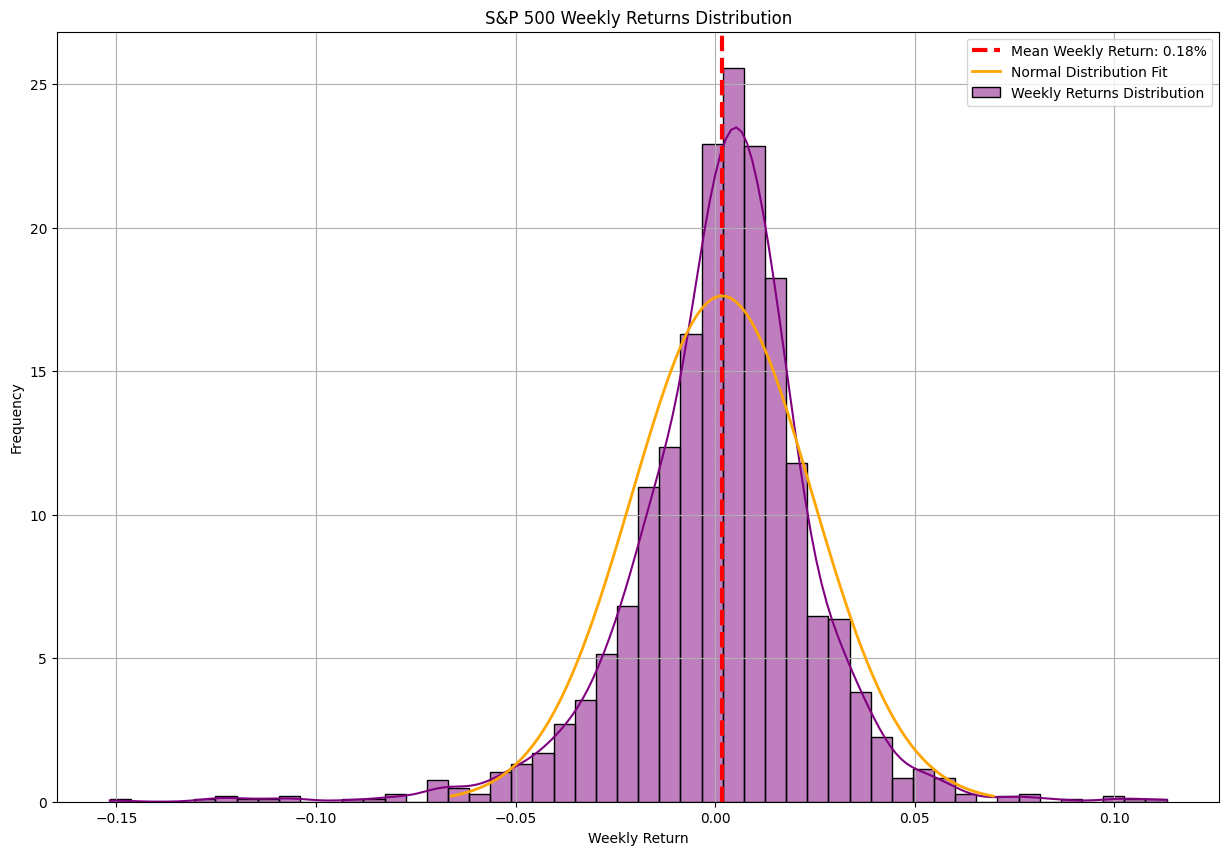

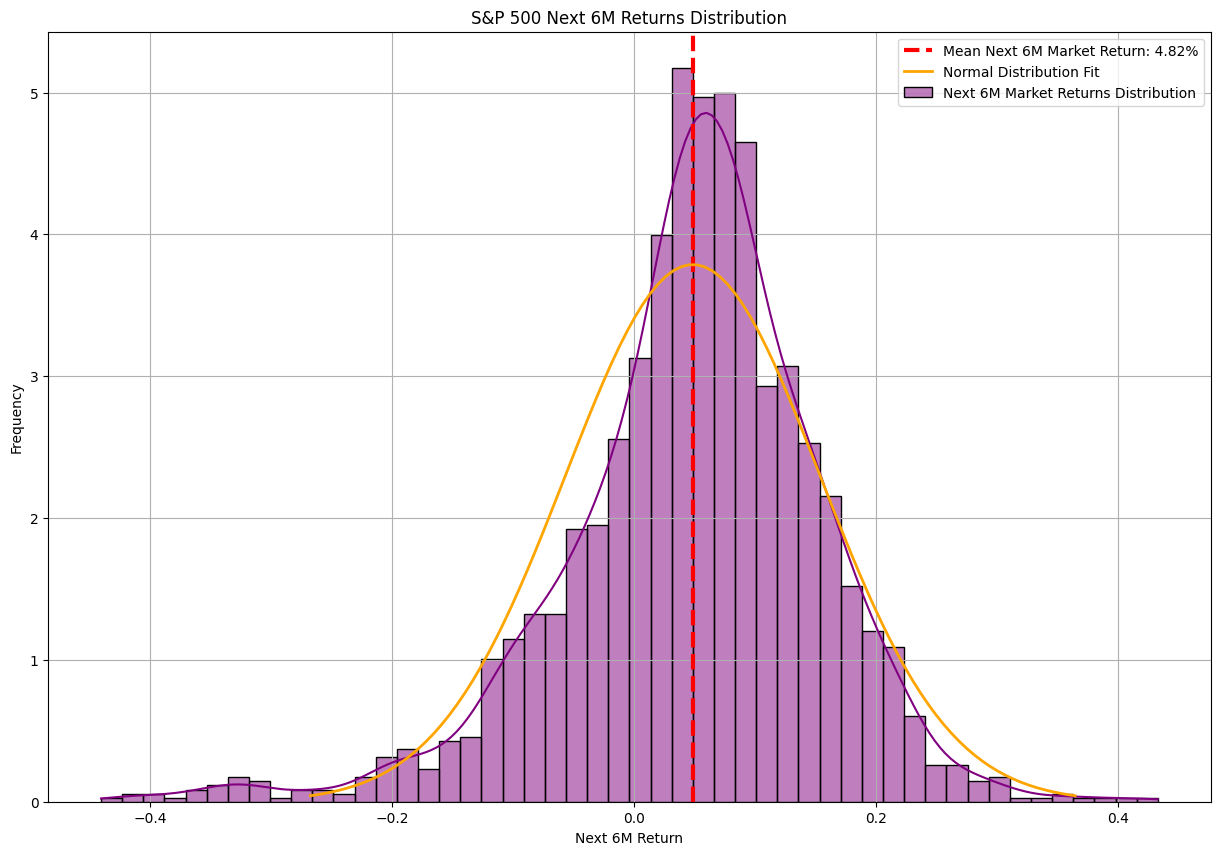

In [62]:
plt.figure(figsize=(15,10))
sns.histplot(data=s_df, x='Weekly Return', bins=50, kde=True, stat='density', color='purple', label='Weekly Returns Distribution')
plt.axvline(s_df['Weekly Return'].mean(), color='red', linestyle='dashed', linewidth=3, label=f'Mean Weekly Return: {s_df["Weekly Return"].mean()*100:.2f}%')

plt.title('S&P 500 Weekly Returns Distribution')
plt.xlabel('Weekly Return')
plt.ylabel('Frequency')

# Source - https://stackoverflow.com/a/10138308
# Posted by unutbu, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-19, License - CC BY-SA 4.0

mu = s_df['Weekly Return'].mean()
variance = s_df['Weekly Return'].var()
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

sns.lineplot(x=x, y=stats.norm.pdf(x, mu, sigma), color='orange', linewidth=2, label='Normal Distribution Fit')

plt.legend()

plt.grid()
plt.show()

plt.figure(figsize=(15,10))
sns.histplot(data=s_df, x='Next 6M Return', bins=50, kde=True, stat='density', color='purple', label='Next 6M Market Returns Distribution')
plt.axvline(s_df['Next 6M Return'].mean(), color='red', linestyle='dashed', linewidth=3, label=f'Mean Next 6M Market Return: {s_df["Next 6M Return"].mean()*100:.2f}%')

plt.title('S&P 500 Next 6M Returns Distribution')
plt.xlabel('Next 6M Return')
plt.ylabel('Frequency')

# Source - https://stackoverflow.com/a/10138308
# Posted by unutbu, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-19, License - CC BY-SA 4.0

mu = s_df['Next 6M Return'].mean()
variance = s_df['Next 6M Return'].var()
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

sns.lineplot(x=x, y=stats.norm.pdf(x, mu, sigma), color='orange', linewidth=2, label='Normal Distribution Fit')

plt.legend()

plt.grid()
plt.show()

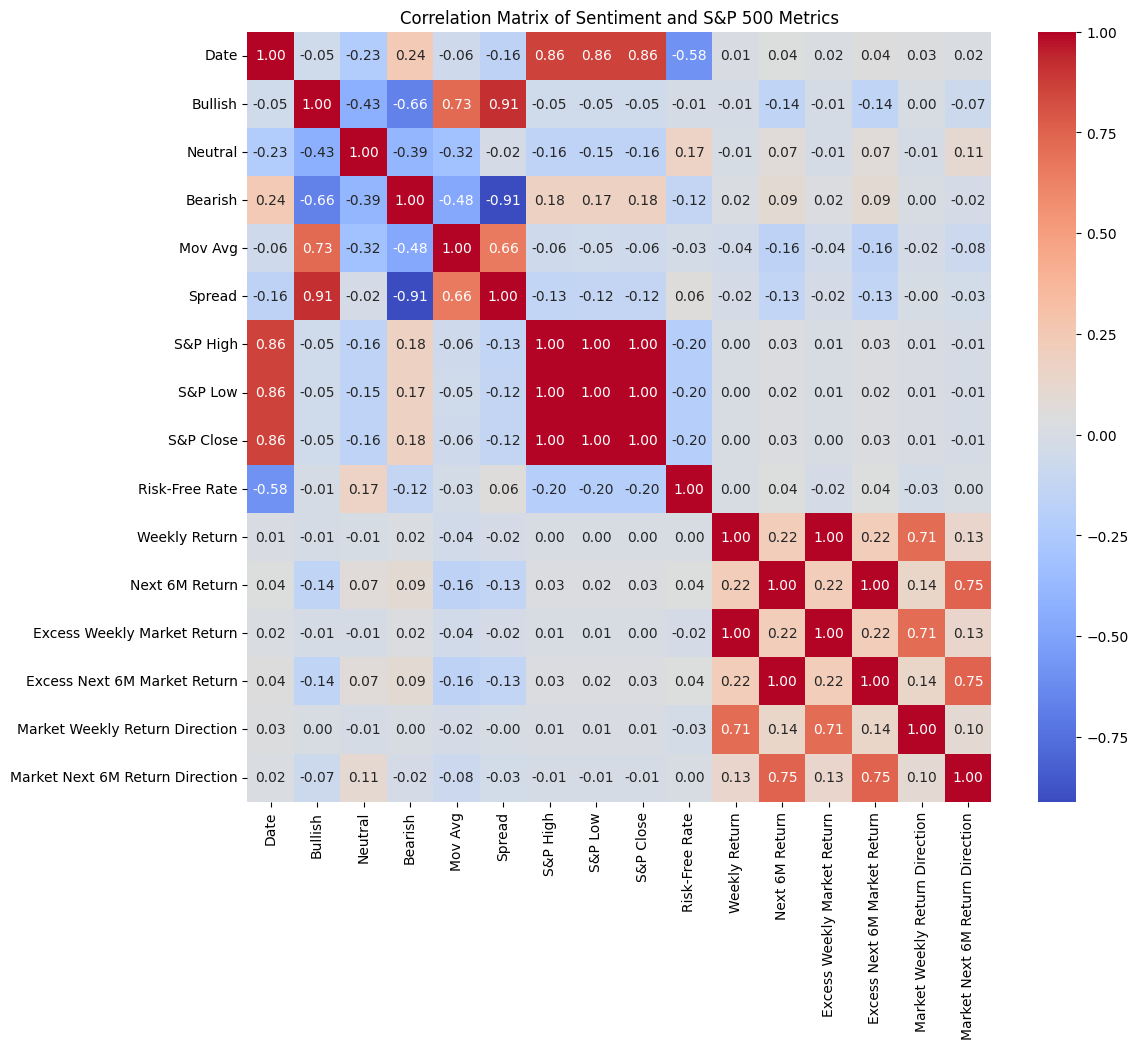

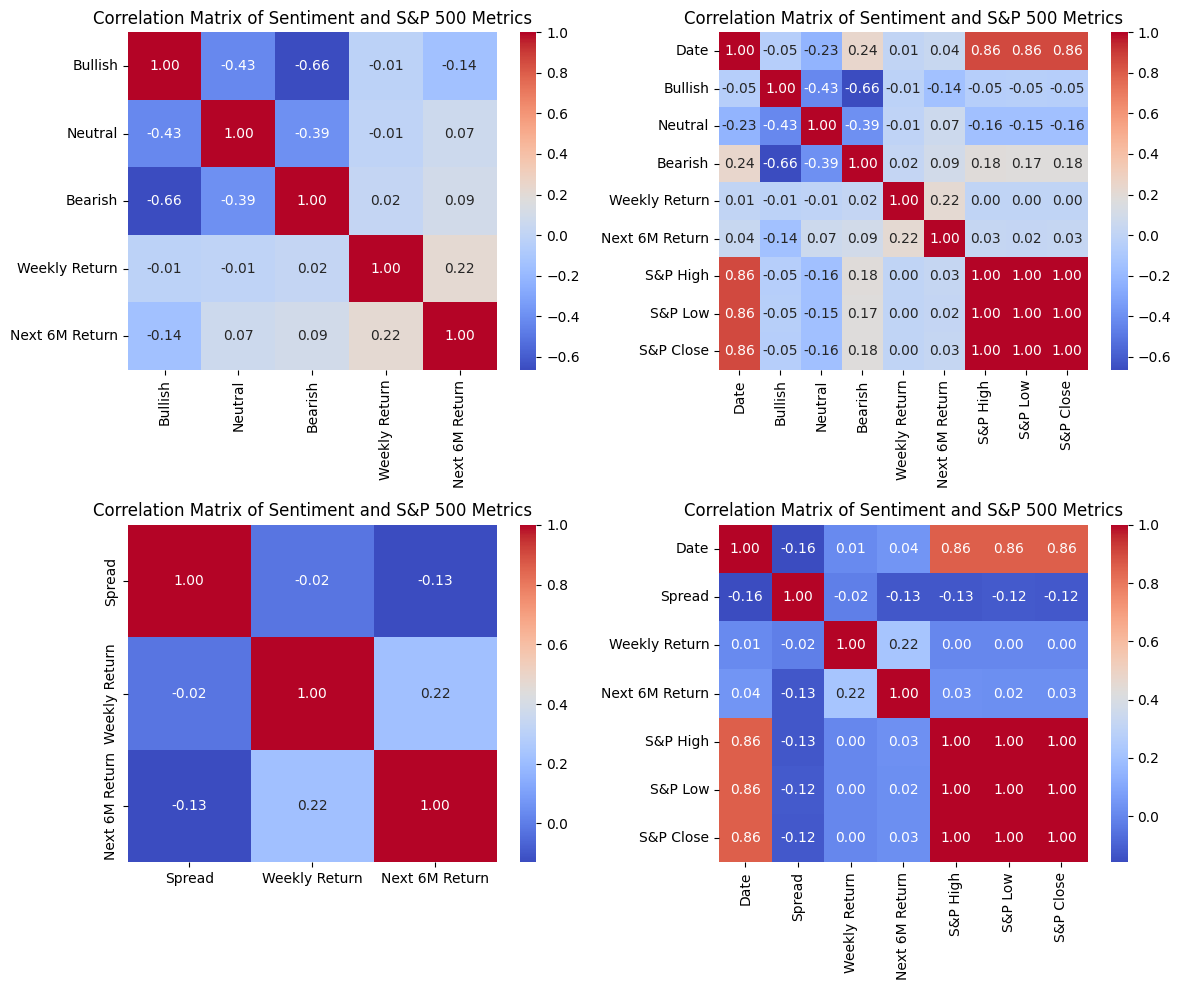

In [39]:
fig, ax = plt.subplots(1,1, figsize=(12,10))

plot_correlation_matrix(dataframe = s_df, columns = s_df.columns, ax=ax)

plt.show()


fig, ax = plt.subplots(2,2, figsize=(12,10))

plot_correlation_matrix(dataframe = s_df, columns = ['Bullish', 'Neutral', 'Bearish', 'Weekly Return', 'Next 6M Return'], ax=ax[0,0])

plot_correlation_matrix(dataframe = s_df, columns = ['Date', 'Bullish', 'Neutral', 'Bearish', 'Weekly Return', 'Next 6M Return', 'S&P High', 'S&P Low', 'S&P Close'], ax=ax[0,1])



plot_correlation_matrix(dataframe = s_df, columns = ['Spread', 'Weekly Return', 'Next 6M Return'], ax=ax[1,0])

plot_correlation_matrix(dataframe = s_df, columns = ['Date', 'Spread', 'Weekly Return', 'Next 6M Return', 'S&P High', 'S&P Low', 'S&P Close'], ax=ax[1,1])



plt.tight_layout()
plt.show()




In [40]:
signal = calculate_sentiment_signal(s_df.Spread, threshold=0)

In [41]:
s_df['Signal'] = signal

In [42]:
display(s_df[['Date', 'Spread', 'Signal']].head())

,Date,Spread,Signal
1,1987-06-26,NaN,0
2,1987-07-17,NaN,0
3,1987-07-24,0.22,1
4,1987-07-31,0.00,0
5,1987-08-07,0.27,1


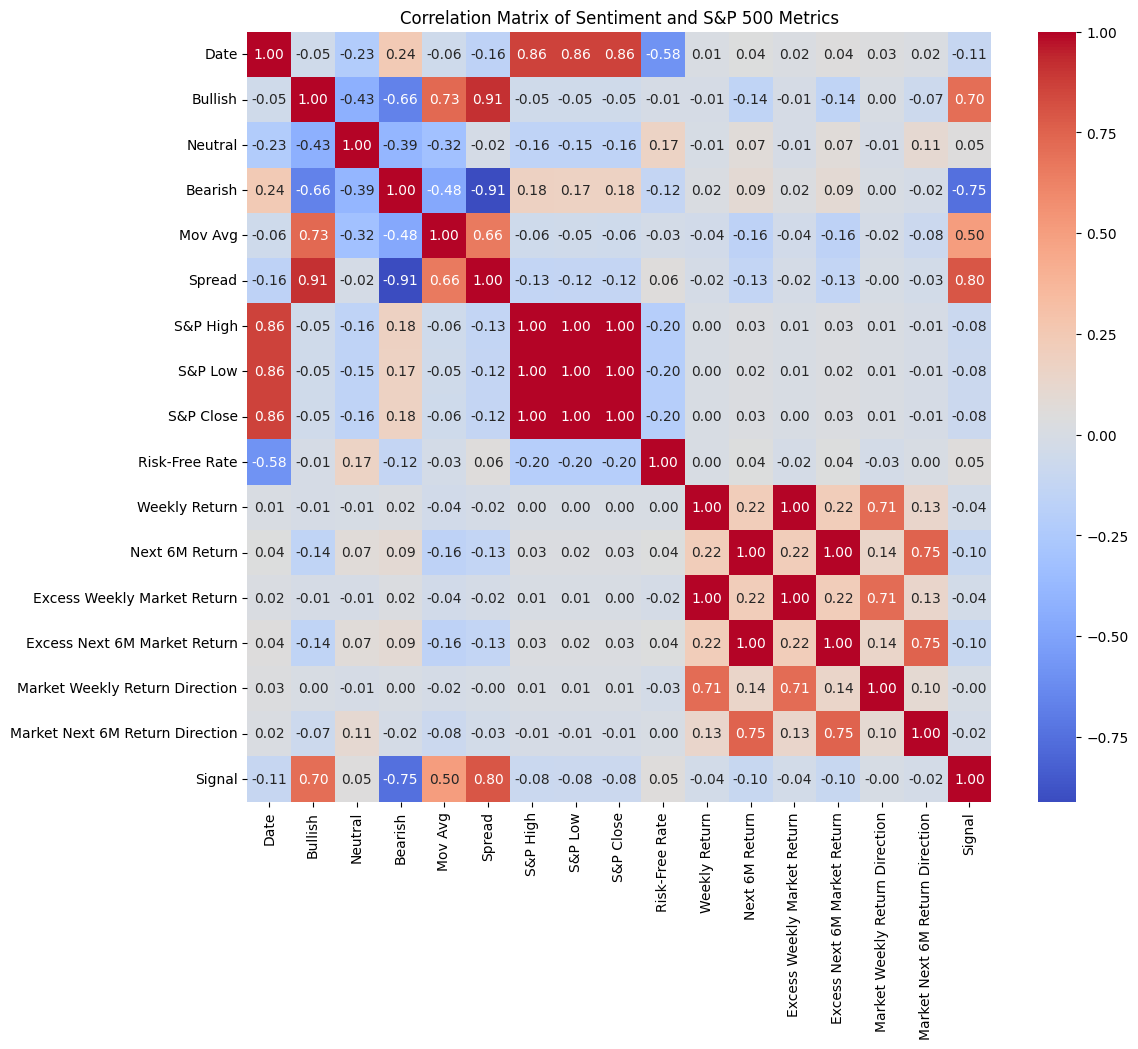

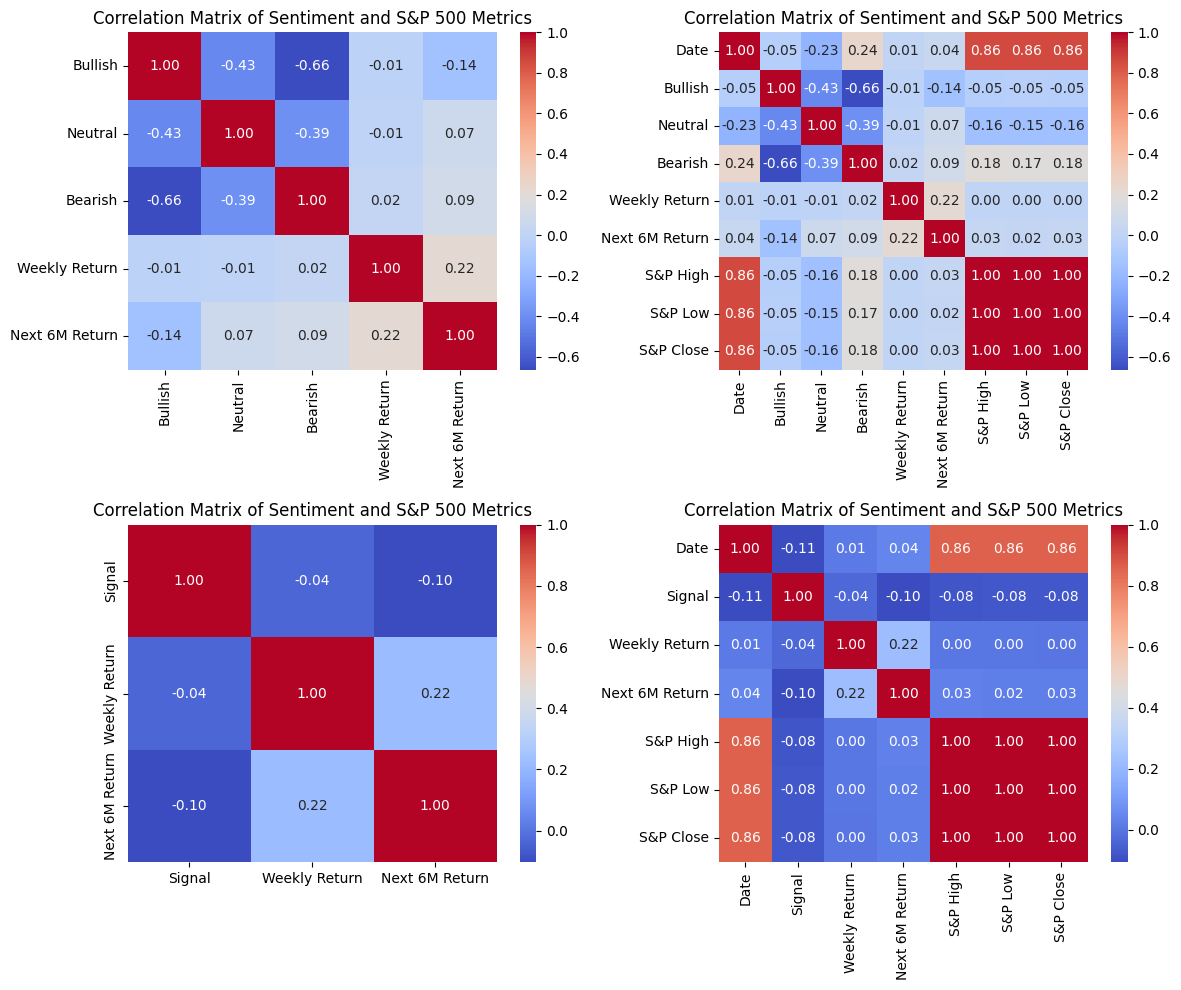

In [43]:
fig, ax = plt.subplots(1,1, figsize=(12,10))

plot_correlation_matrix(dataframe = s_df, columns = s_df.columns, ax=ax)

plt.show()


fig, ax = plt.subplots(2,2, figsize=(12,10))

plot_correlation_matrix(dataframe = s_df, columns = ['Bullish', 'Neutral', 'Bearish', 'Weekly Return', 'Next 6M Return'], ax=ax[0,0])

plot_correlation_matrix(dataframe = s_df, columns = ['Date', 'Bullish', 'Neutral', 'Bearish', 'Weekly Return', 'Next 6M Return', 'S&P High', 'S&P Low', 'S&P Close'], ax=ax[0,1])



plot_correlation_matrix(dataframe = s_df, columns = ['Signal', 'Weekly Return', 'Next 6M Return'], ax=ax[1,0])

plot_correlation_matrix(dataframe = s_df, columns = ['Date', 'Signal', 'Weekly Return', 'Next 6M Return', 'S&P High', 'S&P Low', 'S&P Close'], ax=ax[1,1])



plt.tight_layout()
plt.show()


In [44]:
returns = calculate_return(s_df['Signal'], s_df['Excess Weekly Market Return'])

s_df['Strategy Return'] = returns

display(s_df)

/var/folders/z0/72gknplj1v3dgx7k897dbd3m0000gn/T/ipykernel_45607/2340871519.py:1: RuntimeWarning: NaN detected in signal/returns; using flat signal for missing signal and preserving NaN returns.
  returns = calculate_return(s_df['Signal'], s_df['Excess Weekly Market Return'])


,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,Risk-Free Rate,Weekly Return,Next 6M Return,Excess Weekly Market Return,Excess Next 6M Market Return,Market Weekly Return Direction,Market Next 6M Return Direction,Signal,Strategy Return
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001110,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59,0.001073,-0.016911,-0.198798,-0.017984,-0.199872,-1.0,-1.0,0,-0.000000
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27,0.001088,0.030362,-0.202962,0.029273,-0.204050,1.0,-1.0,1,0.029273
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66,0.001142,0.013620,-0.193278,0.012477,-0.194420,1.0,-1.0,0,0.012477
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00,0.001129,0.034025,-0.223034,0.032896,-0.224163,1.0,-1.0,1,0.032896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50,0.000692,-0.013640,NaN,-0.014332,NaN,-1.0,NaN,-1,0.014332
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80,0.000692,-0.022300,NaN,-0.022992,NaN,-1.0,NaN,-1,0.022992
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70,0.000694,-0.004951,NaN,-0.005645,NaN,-1.0,NaN,-1,0.005645
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90,0.000696,-0.002515,NaN,-0.003211,NaN,-1.0,NaN,-1,0.003211


In [45]:



s_df['Accuracy'] = np.where(s_df['Signal'] == s_df['Market Weekly Return Direction'], 1, 0)

#s_df.drop(s_df['Date'] == 1987-01-01, inplace=True)

In [47]:
display(s_df.mean())

Date                               2006-11-18 05:40:02.376237
Bullish                                              0.376221
Neutral                                              0.310635
Bearish                                              0.313143
Mov Avg                                              0.375845
Spread                                               0.063077
S&P High                                           1776.07636
S&P Low                                           1729.207499
S&P Close                                         1756.605254
Risk-Free Rate                                       0.000577
Weekly Return                                        0.001766
Next 6M Return                                       0.048164
Excess Weekly Market Return                          0.001189
Excess Next 6M Market Return                         0.047589
Market Weekly Return Direction                       0.135778
Market Next 6M Return Direction                      0.478174
Signal  

In [48]:
s_df['Signal'].value_counts()

Signal
 1    1277
-1     692
 0      51
Name: count, dtype: int64

In [49]:
s_df['Risk-Free Rate'] = rf_data.to_numpy()


display(s_df)


,Date,Bullish,Neutral,Bearish,Mov Avg,Spread,S&P High,S&P Low,S&P Close,Risk-Free Rate,Weekly Return,Next 6M Return,Excess Weekly Market Return,Excess Next 6M Market Return,Market Weekly Return Direction,Market Next 6M Return Direction,Signal,Strategy Return,Accuracy
1,1987-06-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001110,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0
2,1987-07-17,NaN,NaN,NaN,NaN,NaN,314.59,307.63,314.59,0.001073,-0.016911,-0.198798,-0.017984,-0.199872,-1.0,-1.0,0,-0.000000,0
3,1987-07-24,0.360000,0.50000,0.140000,NaN,0.220000,311.39,307.81,309.27,0.001088,0.030362,-0.202962,0.029273,-0.204050,1.0,-1.0,1,0.029273,1
4,1987-07-31,0.260000,0.48000,0.260000,NaN,0.000000,318.66,310.65,318.66,0.001142,0.013620,-0.193278,0.012477,-0.194420,1.0,-1.0,0,0.012477,0
5,1987-08-07,0.560000,0.15000,0.290000,NaN,0.270000,323.00,316.23,323.00,0.001129,0.034025,-0.223034,0.032896,-0.224163,1.0,-1.0,1,0.032896,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,2026-03-05,0.330579,0.31405,0.355372,0.395061,-0.024793,6947.25,6710.42,6869.50,0.000692,-0.013640,NaN,-0.014332,NaN,-1.0,NaN,-1,0.014332,1
2017,2026-03-12,0.319392,0.21673,0.463878,0.373107,-0.144486,6870.43,6636.04,6775.80,0.000692,-0.022300,NaN,-0.022992,NaN,-1.0,NaN,-1,0.022992,1
2018,2026-03-19,0.304000,0.17600,0.520000,0.357151,-0.216000,6754.30,6621.66,6624.70,0.000694,-0.004951,NaN,-0.005645,NaN,-1.0,NaN,-1,0.005645,1
2019,2026-03-26,0.320988,0.18107,0.497942,0.341774,-0.176954,6651.62,6473.52,6591.90,0.000696,-0.002515,NaN,-0.003211,NaN,-1.0,NaN,-1,0.003211,1


In [54]:
strategy_return = ['Strategy Return']

strat_reg = fit_ols(s_df.dropna(), strategy_return[0], 'Excess Weekly Market Return')

                            OLS Regression Results                            
Dep. Variable:        Strategy Return   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     8.581
Date:                Mon, 20 Apr 2026   Prob (F-statistic):            0.00344
Time:                        17:15:39   Log-Likelihood:                 4679.5
No. Observations:                1977   AIC:                            -9355.
Df Residuals:                    1975   BIC:                            -9344.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:

# display('Strategy Regression Summary: \n', strat_reg.summary())

# display('Long Leg Regression Summary: \n', long_leg_reg.summary())

# display('Short Leg Regression Summary: \n', short_leg_reg.summary())

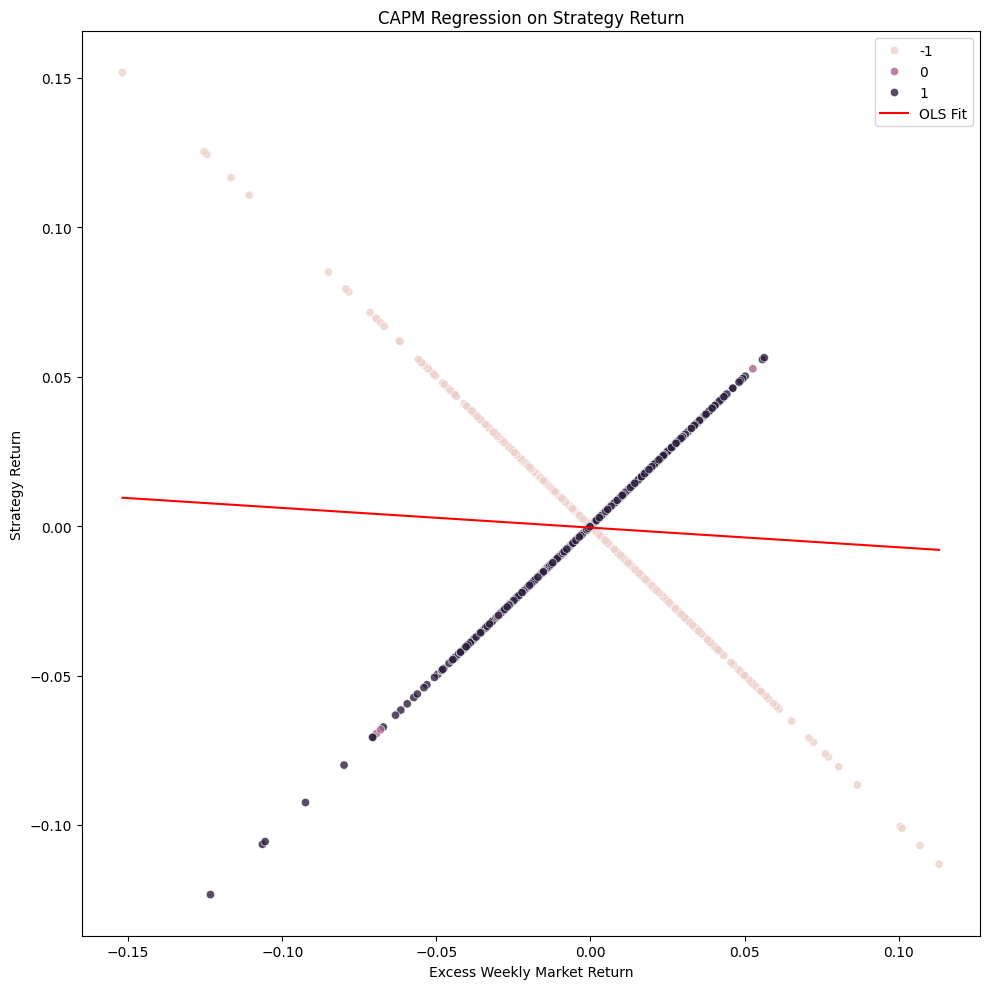

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

models = [strat_reg]

for idx, (model, portfolio) in enumerate(zip(models, strategy_return)):

    plot_regression(s_df, model, portfolio, 'Excess Weekly Market Return', ax=ax)

fig.tight_layout()
plt.show()

In [61]:
sharpe_ratio = s_df['Strategy Return'].mean()/np.sqrt(s_df['Strategy Return'].var())

print(f'Sharpe Ratio = {sharpe_ratio}')

Sharpe Ratio = -0.02263312059653675


In [70]:
signal_regression = fit_ols(s_df.dropna(), 'Excess Next 6M Market Return', 'Signal')



                                 OLS Regression Results                                 
Dep. Variable:     Excess Next 6M Market Return   R-squared:                       0.010
Model:                                      OLS   Adj. R-squared:                  0.009
Method:                           Least Squares   F-statistic:                     19.88
Date:                          Mon, 20 Apr 2026   Prob (F-statistic):           8.73e-06
Time:                                  17:36:23   Log-Likelihood:                 1670.2
No. Observations:                          1977   AIC:                            -3336.
Df Residuals:                              1975   BIC:                            -3325.
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

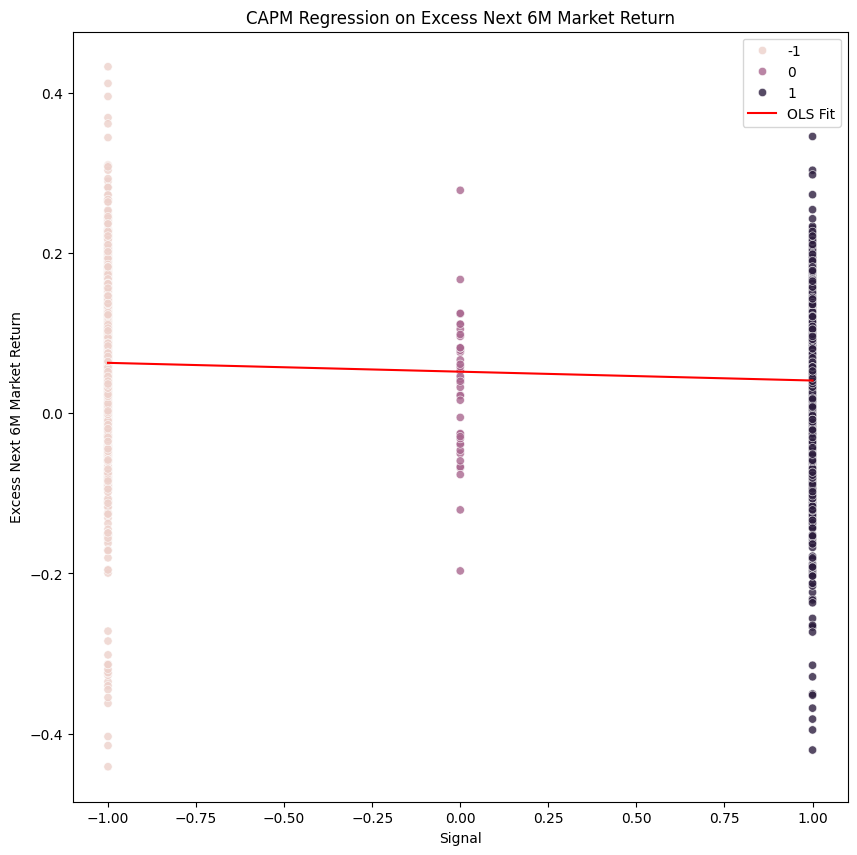

In [75]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

plot_regression(s_df, signal_regression, 'Excess Next 6M Market Return', 'Signal', ax)

plt.show()